In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline


In [ ]:
# Load dataset
df = pd.read_csv("HepatitisCdata_1.csv", sep=';') # sep (separator) untuk pemisah di file csvnya

# Cek 5 baris awal
df.head()


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [ ]:
# Informasi dataset
df.info()

# Cek missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


,0
Unnamed: 0,0
Category,0
Age,0
Sex,0
ALB,1
ALP,18
ALT,1
AST,0
BIL,0
CHE,0


/tmp/ipython-input-446535992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Category", data=df, palette="Set2")


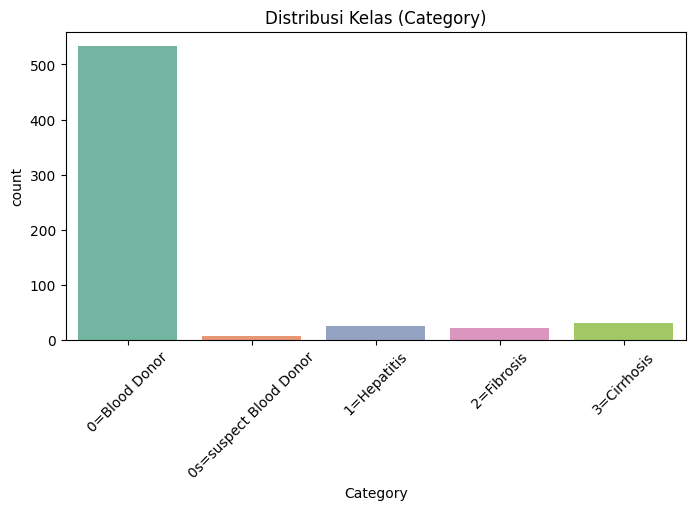

/tmp/ipython-input-446535992.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sex", data=df, palette="Set1")


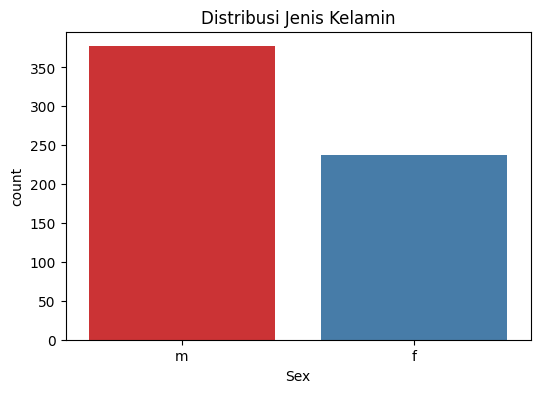

In [ ]:
# Distribusi target class
plt.figure(figsize=(8,4))
sns.countplot(x="Category", data=df, palette="Set2")
plt.title("Distribusi Kelas (Category)")
plt.xticks(rotation=45)
plt.show()

# Distribusi Sex
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df, palette="Set1")
plt.title("Distribusi Jenis Kelamin")
plt.show()


In [ ]:
# Ringkasan Distribusi & Statistik per Class

print("Probabilitas Class")
class_prob = df['Category'].value_counts(normalize=True)
print(class_prob, "\n")

print("Probabilitas Sex")
sex_prob = df['Sex'].value_counts(normalize=True)
print(sex_prob, "\n")

print("Rata-rata Tiap Fitur per Class")
mean_per_class = df.groupby("Category")[['Age','ALB','ALP','ALT','AST','BIL','CHE','CHOL','CREA','GGT','PROT']].mean()
print(mean_per_class)


Probabilitas Class
Category
0=Blood Donor             0.866667
3=Cirrhosis               0.048780
1=Hepatitis               0.039024
2=Fibrosis                0.034146
0s=suspect Blood Donor    0.011382
Name: proportion, dtype: float64 

Probabilitas Sex
Sex
m    0.613008
f    0.386992
Name: proportion, dtype: float64 

Rata-rata Tiap Fitur per Class
                              Age        ALB         ALP         ALT  \
Category                                                               
0=Blood Donor           47.131332  42.238274   68.365103   26.631520   
0s=suspect Blood Donor  57.571429  24.400000  107.300000  102.114286   
1=Hepatitis             38.708333  43.833333   42.114286   26.900000   
2=Fibrosis              52.333333  41.761905   37.841667   59.600000   
3=Cirrhosis             53.466667  32.482759   93.220833   22.970000   

                               AST        BIL       CHE      CHOL        CREA  \
Category                                                     

In [ ]:
# Statistik deskriptif semua kolom
df.describe().T

# Statistik rata-rata per class
df.groupby("Category").mean(numeric_only=True)


,Unnamed: 0,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
Category,,,,,,,,,,,,
0=Blood Donor,267.0,47.131332,42.238274,68.365103,26.631520,26.549156,8.527580,8.398086,5.494316,78.977486,29.036773,72.111257
0s=suspect Blood Donor,537.0,57.571429,24.400000,107.300000,102.114286,71.000000,4.685714,7.480000,4.451429,61.714286,151.514286,53.914286
1=Hepatitis,552.5,38.708333,43.833333,42.114286,26.900000,75.733333,15.625000,9.283750,5.099167,73.958333,92.579167,74.700000
2=Fibrosis,575.0,52.333333,41.761905,37.841667,59.600000,81.171429,13.428571,8.334762,4.595500,73.490476,79.552381,76.100000
3=Cirrhosis,600.5,53.466667,32.482759,93.220833,22.970000,107.456667,59.133333,3.818333,4.008571,138.223333,129.440000,70.051724


In [ ]:
# Preprocessing data

# Hapus kolom ID
df = df.drop(columns=["Unnamed: 0"])

# Encode kolom Sex
df["Sex"] = df["Sex"].map({"m": 0, "f": 1})

# Cek missing values numerik -> isi menggunakan nilai median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Pastikan tidak ada NaN lagi
print(df.isnull().sum().sum(), "missing values tersisa")

0 missing values tersisa


In [ ]:
# Pemisahan fitur dan target
X = df.drop("Category", axis=1)
y = df["Category"]

# Split train-test stratified (agar distribusi class terjaga)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (492, 12) Test size: (123, 12)


In [ ]:
# Pipeline tanpa PCA
pipe_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

# Train model
pipe_nb.fit(X_train, y_train)

# Prediksi
y_pred_nb = pipe_nb.predict(X_test)

# Evaluasi
print("=== Evaluasi Model Naive Bayes (Tanpa PCA) ===")
print(classification_report(y_test, y_pred_nb))


=== Evaluasi Model Naive Bayes (Tanpa PCA) ===
                        precision    recall  f1-score   support

         0=Blood Donor       0.97      0.98      0.98       107
0s=suspect Blood Donor       0.33      1.00      0.50         1
           1=Hepatitis       0.67      0.40      0.50         5
            2=Fibrosis       0.50      0.50      0.50         4
           3=Cirrhosis       1.00      0.83      0.91         6

              accuracy                           0.93       123
             macro avg       0.69      0.74      0.68       123
          weighted avg       0.94      0.93      0.93       123



In [ ]:
# Tentukan jumlah komponen PCA yang menjelaskan ≥90% varians
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA().fit(X_scaled)

cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumsum_var >= 0.90) + 1

print(f"Jumlah komponen PCA untuk ≥90% varians: {n_components}")

# Pipeline dengan PCA
pipe_pca_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components)),
    ("nb", GaussianNB())
])

pipe_pca_nb.fit(X_train, y_train)
y_pred_pca_nb = pipe_pca_nb.predict(X_test)

print("Evaluasi Model Naive Bayes (Dengan PCA)")
print(classification_report(y_test, y_pred_pca_nb))


Jumlah komponen PCA untuk ≥90% varians: 9
Evaluasi Model Naive Bayes (Dengan PCA)
                        precision    recall  f1-score   support

         0=Blood Donor       0.96      0.97      0.97       107
0s=suspect Blood Donor       0.25      1.00      0.40         1
           1=Hepatitis       0.40      0.40      0.40         5
            2=Fibrosis       1.00      0.50      0.67         4
           3=Cirrhosis       0.75      0.50      0.60         6

              accuracy                           0.91       123
             macro avg       0.67      0.67      0.61       123
          weighted avg       0.93      0.91      0.91       123



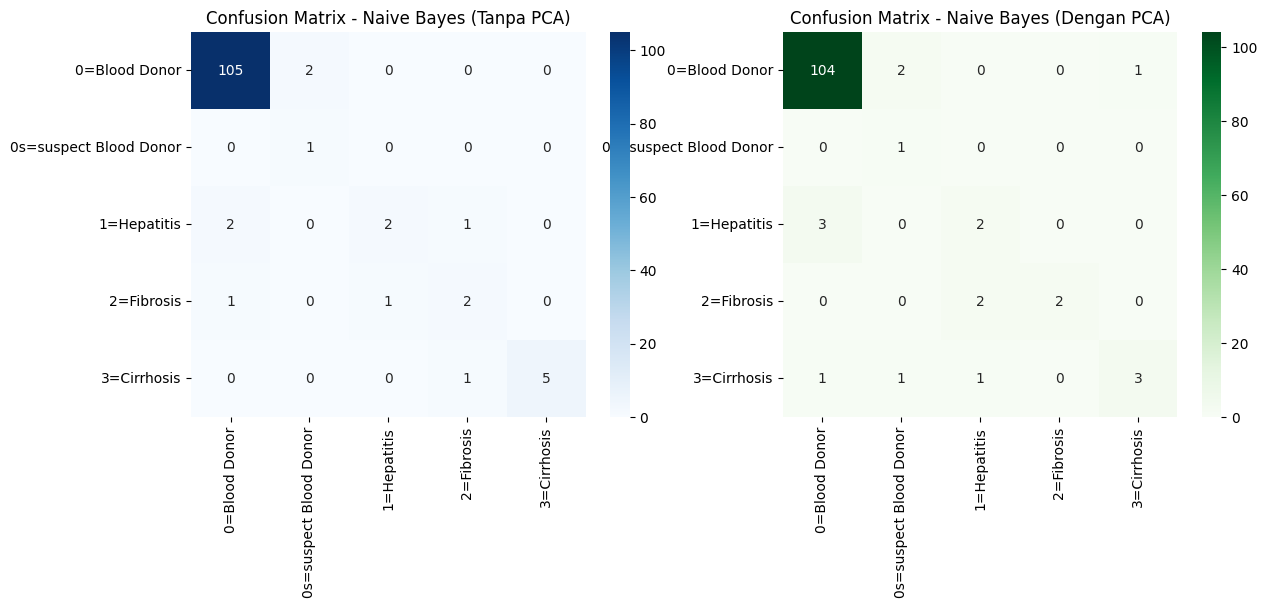

In [ ]:
# Visualisasi confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Tanpa PCA
cm1 = confusion_matrix(y_test, y_pred_nb, labels=pipe_nb.classes_)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=pipe_nb.classes_, yticklabels=pipe_nb.classes_)
axes[0].set_title("Confusion Matrix - Naive Bayes (Tanpa PCA)")

# Dengan PCA
cm2 = confusion_matrix(y_test, y_pred_pca_nb, labels=pipe_pca_nb.classes_)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=pipe_pca_nb.classes_, yticklabels=pipe_pca_nb.classes_)
axes[1].set_title("Confusion Matrix - Naive Bayes (Dengan PCA)")

plt.show()


In [ ]:
# Cross-validation stratified untuk stabilitas hassil

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_score_nb = cross_val_score(pipe_nb, X, y, cv=cv, scoring="f1_macro").mean()
cv_score_pca_nb = cross_val_score(pipe_pca_nb, X, y, cv=cv, scoring="f1_macro").mean()

print(f"F1-macro CV (Tanpa PCA): {cv_score_nb:.4f}")
print(f"F1-macro CV (Dengan PCA): {cv_score_pca_nb:.4f}")


F1-macro CV (Tanpa PCA): 0.5852
F1-macro CV (Dengan PCA): 0.5235


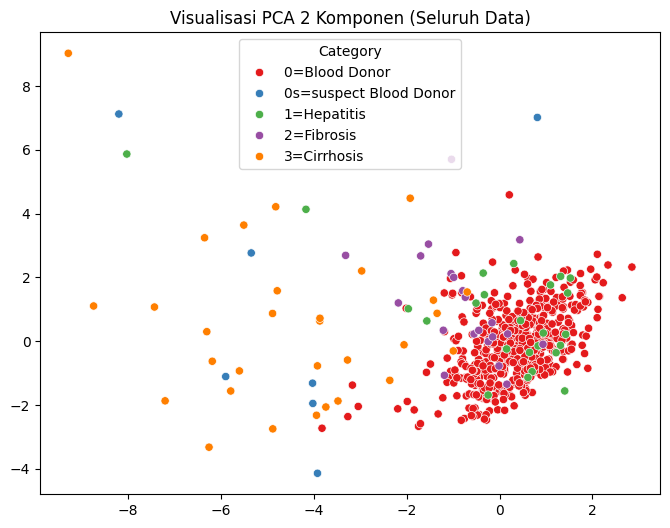

In [ ]:
# Visualisasi PCA dengan 2 komponen untuk data keseluruhan

X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca_2d[:,0], y=X_pca_2d[:,1], hue=y, palette="Set1")
plt.title("Visualisasi PCA 2 Komponen (Seluruh Data)")
plt.show()


# Testing New Data

In [ ]:
# Prediksi Data Baru
new_data = pd.DataFrame([{
    "Age": 45,
    "Sex": 0,      # 0 = male, 1 = female
    "ALB": 40.0,
    "ALP": 60.0,
    "ALT": 25.0,
    "AST": 30.0,
    "BIL": 8.0,
    "CHE": 6.5,
    "CHOL": 4.5,
    "CREA": 90.0,
    "GGT": 20.0,
    "PROT": 70.0
}])

# Model 1: Naive Bayes tanpa PCA
pred_class_nb = pipe_nb.predict(new_data)[0]
pred_proba_nb = pipe_nb.predict_proba(new_data)[0]

print("=== Prediksi dengan Naive Bayes (Tanpa PCA) ===")
print("Hasil Prediksi Kategori:", pred_class_nb)
print("Probabilitas Tiap Kelas:")
for cls, prob in zip(pipe_nb.classes_, pred_proba_nb):
    print(f"{cls} : {prob:.4f}")

print("\n")

# Model 2: Naive Bayes dengan PCA
pred_class_pca = pipe_pca_nb.predict(new_data)[0]
pred_proba_pca = pipe_pca_nb.predict_proba(new_data)[0]

print("=== Prediksi dengan Naive Bayes (Dengan PCA) ===")
print("Hasil Prediksi Kategori:", pred_class_pca)
print("Probabilitas Tiap Kelas:")
for cls, prob in zip(pipe_pca_nb.classes_, pred_proba_pca):
    print(f"{cls} : {prob:.4f}")


=== Prediksi dengan Naive Bayes (Tanpa PCA) ===
Hasil Prediksi Kategori: 0=Blood Donor
Probabilitas Tiap Kelas:
0=Blood Donor : 0.9998
0s=suspect Blood Donor : 0.0000
1=Hepatitis : 0.0000
2=Fibrosis : 0.0002
3=Cirrhosis : 0.0000


=== Prediksi dengan Naive Bayes (Dengan PCA) ===
Hasil Prediksi Kategori: 0=Blood Donor
Probabilitas Tiap Kelas:
0=Blood Donor : 0.9990
0s=suspect Blood Donor : 0.0000
1=Hepatitis : 0.0002
2=Fibrosis : 0.0007
3=Cirrhosis : 0.0000


In [ ]:
# === AUTO-GENERATED THUMBNAIL EXPORT ===
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

# Find all existing figure axes
figures = [plt.figure(i) for i in plt.get_fignums()]
if figures:
    fig = figures[-1]  # Use last figure
else:
    # Create a summary figure from available data
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.text(0.5, 0.5, 'Project Visualization', fontsize=24, 
            ha='center', va='center', transform=ax.transAxes,
            fontweight='bold', color='#2d3436')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')
    ax.axis('off')

thumbnail_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'thumbnail.png')
fig.savefig(thumbnail_path, dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print(f"✅ Thumbnail saved: {thumbnail_path}")
plt.show()
